In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [4]:
team_stats = pd.read_csv('Agg_Team_Data_2000-2024.csv')
team_stats = team_stats.fillna(0)

In [5]:
#predicting playoff wins and playoff tier reached
team_stats_filtered = team_stats[team_stats["playoff_games"] > 0]
team_stats_filtered

,season,teamId,teamName,games_played,wins,losses,avg_points,avg_opponent_points,avg_point_diff,fg_pct,...,personal_fouls,plus_minus_pts,off_efficiency,win_pct,avg_margin,playoff_games,playoff_wins,playoff_losses,payroll,inflationAdjPayroll
4,2000,1610612742,Mavericks,82,53,29,100.48,96.20,4.28,0.46,...,23.26,4.28,0.55,0.65,4.28,10.0,4.0,6.0,52274842.0,89846921.0
9,2000,1610612747,Lakers,82,56,26,100.62,97.24,3.38,0.47,...,22.83,3.38,0.50,0.68,3.38,16.0,15.0,1.0,58968213.0,101351093.0
10,2000,1610612748,Heat,82,50,32,88.89,86.60,2.29,0.43,...,21.05,2.29,0.51,0.61,2.29,3.0,0.0,3.0,73472329.0,126279916.0
11,2000,1610612749,Bucks,82,52,30,100.73,96.85,4.20,0.46,...,23.51,4.20,0.54,0.63,3.88,18.0,10.0,8.0,57819318.0,99376441.0
12,2000,1610612750,Timberwolves,82,47,35,97.34,95.99,1.64,0.46,...,23.17,1.64,0.53,0.57,1.35,4.0,1.0,3.0,47488500.0,81620437.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762,2024,1610612753,Magic,82,41,41,104.01,104.27,-0.25,0.45,...,20.16,-0.25,0.51,0.50,-0.26,5.0,1.0,4.0,123147189.0,123147189.0
763,2024,1610612754,Pacers,82,50,32,117.37,115.13,2.23,0.49,...,18.70,2.23,0.55,0.61,2.23,23.0,15.0,8.0,126338563.0,126338563.0
769,2024,1610612760,Thunder,83,68,15,120.02,107.51,12.52,0.48,...,19.82,12.52,0.56,0.82,12.52,23.0,16.0,7.0,142314490.0,142314490.0
772,2024,1610612763,Grizzlies,82,48,34,121.71,116.85,4.90,0.48,...,20.87,4.90,0.54,0.59,4.85,4.0,0.0,4.0,109430560.0,109430560.0


In [6]:
team_stats_filtered["playoff_tier"] = np.select(
    [
        team_stats_filtered["playoff_wins"] == 0,
        team_stats_filtered["playoff_wins"] <= 3,
        team_stats_filtered["playoff_wins"] <= 7,
        team_stats_filtered["playoff_wins"] <= 11,
        team_stats_filtered["playoff_wins"] <= 16,
        team_stats_filtered["playoff_wins"] > 16
    ],
    [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
)

C:\Users\chris\AppData\Local\Temp\ipykernel_48396\3003662522.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  team_stats_filtered["playoff_tier"] = np.select(


In [7]:
team_stats_params = team_stats_filtered.drop(columns=["playoff_wins","playoff_tier","playoff_games","playoff_losses", "teamName"])

In [8]:
X_tiers = team_stats_params
y_tiers = team_stats_filtered["playoff_tier"]

In [9]:
X_wins = team_stats_params
y_wins = team_stats_filtered["playoff_wins"]

In [10]:
X_train_tiers, X_test_tiers, y_train_tiers, y_test_tiers = train_test_split(
    X_tiers, y_tiers, test_size=0.2, random_state=1234
)

rf_tiers = RandomForestClassifier(
    n_estimators=500,
    random_state=1234,
    max_depth=None,
    min_samples_split=2
)

rf_tiers.fit(X_train_tiers, y_train_tiers)

RandomForestClassifier(n_estimators=500, random_state=1234)

In [11]:
X_train_wins, X_test_wins, y_train_wins, y_test_wins = train_test_split(
    X_wins, y_wins, test_size=0.2, random_state=1234
)

rf_wins = RandomForestClassifier(
    n_estimators=500,
    random_state=1234,
    max_depth=None,
    min_samples_split=2
)

rf_wins.fit(X_train_wins, y_train_wins)

RandomForestClassifier(n_estimators=500, random_state=1234)

In [12]:
y_pred_tiers = rf_tiers.predict(X_test_tiers)

mse = mean_squared_error(y_test_tiers, y_pred_tiers)

print("MSE:", mse)

MSE: 0.9012345679012346


In [13]:
y_pred_wins = rf_wins.predict(X_test_wins)

mse = mean_squared_error(y_test_wins, y_pred_wins)

print("MSE:", mse)

MSE: 19.962962962962962


In [14]:
results = pd.DataFrame({
    "actual playoff wins": y_test_wins,
    "predicted playoff wins": y_pred_wins,
    "actual playoff tier": y_test_tiers,
    "predicted playoff tier": y_pred_tiers
}, index=X_test_tiers.index)
 
full_results = pd.concat([results, X_test_tiers], axis=1)

full_results.head(50)

,actual playoff wins,predicted playoff wins,actual playoff tier,predicted playoff tier,season,teamId,games_played,wins,losses,avg_points,...,lead_changes,def_rebounds,off_rebounds,personal_fouls,plus_minus_pts,off_efficiency,win_pct,avg_margin,payroll,inflationAdjPayroll
204,10.0,2.0,3.0,3.0,2006,1610612765,82,53,29,96.00,...,0.00,28.95,11.56,20.39,4.16,0.52,0.65,4.16,59010951.0,8.617837e+07
756,1.0,1.0,1.0,1.0,2024,1610612747,80,49,31,113.45,...,6.38,32.69,9.65,17.35,1.09,0.55,0.61,1.09,196866948.0,1.968669e+08
457,7.0,0.0,2.0,1.0,2015,1610612748,82,48,34,100.05,...,0.00,34.28,9.84,18.32,1.65,0.52,0.59,1.65,85764781.0,1.064920e+08
496,0.0,0.0,0.0,1.0,2016,1610612757,82,41,41,107.94,...,0.00,33.54,10.12,21.17,-0.26,0.54,0.50,-0.52,119732234.0,1.472005e+08
79,7.0,10.0,2.0,3.0,2002,1610612758,82,59,23,101.73,...,0.00,33.55,10.98,20.32,6.50,0.53,0.72,6.50,70416596.0,1.159823e+08
528,1.0,1.0,1.0,1.0,2017,1610612759,82,47,35,102.73,...,0.00,33.87,10.35,17.17,2.89,0.53,0.57,2.89,114633844.0,1.386674e+08
180,6.0,2.0,2.0,1.0,2006,1610612741,82,49,33,98.78,...,0.00,31.67,12.00,23.27,5.01,0.53,0.60,5.01,54754904.0,7.996293e+07
553,0.0,3.0,0.0,1.0,2018,1610612754,82,48,34,108.01,...,0.00,33.73,9.29,19.44,3.33,0.53,0.59,3.33,110724804.0,1.302000e+08
117,3.0,1.0,1.0,1.0,2004,1610612738,82,45,37,101.27,...,0.00,29.73,11.09,24.39,0.87,0.53,0.55,0.85,64577356.0,1.008697e+08
675,2.0,2.0,1.0,1.0,2021,1610612761,82,48,34,109.39,...,0.00,31.98,13.35,19.60,2.29,0.52,0.59,2.29,134896484.0,1.471178e+08


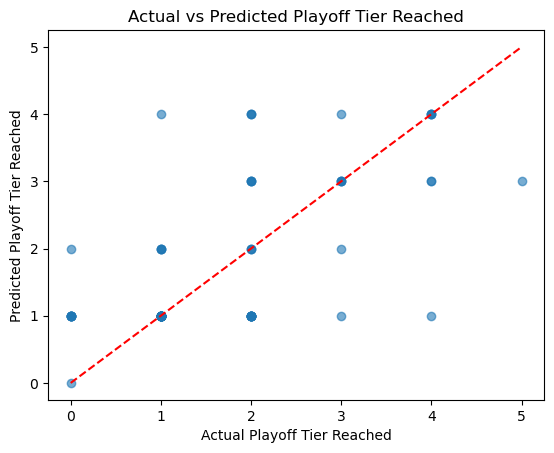

In [15]:
plt.scatter(results["actual playoff tier"], results["predicted playoff tier"], alpha=0.6)
plt.xlabel("Actual Playoff Tier Reached")
plt.ylabel("Predicted Playoff Tier Reached")
plt.title("Actual vs Predicted Playoff Tier Reached")
plt.plot([0, results["actual playoff tier"].max()], [0, results["actual playoff tier"].max()], 'r--')
plt.show()

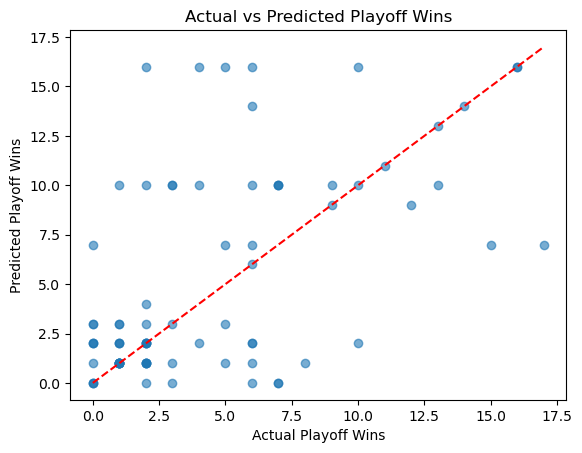

In [16]:
plt.scatter(results["actual playoff wins"], results["predicted playoff wins"], alpha=0.6)
plt.xlabel("Actual Playoff Wins")
plt.ylabel("Predicted Playoff Wins")
plt.title("Actual vs Predicted Playoff Wins")
plt.plot([0, results["actual playoff wins"].max()], [0, results["actual playoff wins"].max()], 'r--')
plt.show()

In [17]:
#look into predicting next years win total
team_stats

,season,teamId,teamName,games_played,wins,losses,avg_points,avg_opponent_points,avg_point_diff,fg_pct,...,personal_fouls,plus_minus_pts,off_efficiency,win_pct,avg_margin,playoff_games,playoff_wins,playoff_losses,payroll,inflationAdjPayroll
0,2000,1610612737,Hawks,82,25,57,90.96,96.17,-5.00,0.43,...,22.72,-5.00,0.52,0.30,-5.21,0.0,0.0,0.0,39297129.0,6.754159e+07
1,2000,1610612738,Celtics,82,36,46,94.62,96.76,-2.13,0.43,...,23.80,-2.13,0.51,0.44,-2.13,0.0,0.0,0.0,51478707.0,8.847857e+07
2,2000,1610612739,Cavaliers,82,30,52,92.21,96.45,-4.24,0.44,...,23.22,-4.24,0.51,0.37,-4.24,0.0,0.0,0.0,49780549.0,8.555988e+07
3,2000,1610612741,Bulls,82,15,67,87.57,96.67,-9.10,0.43,...,23.20,-9.10,0.50,0.18,-9.10,0.0,0.0,0.0,29691907.0,5.103270e+07
4,2000,1610612742,Mavericks,82,53,29,100.48,96.20,4.28,0.46,...,23.26,4.28,0.55,0.65,4.28,10.0,4.0,6.0,52274842.0,8.984692e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
771,2024,1610612762,Jazz,82,16,66,110.33,119.87,-9.65,0.45,...,18.93,-9.65,0.53,0.20,-9.54,0.0,0.0,0.0,120288903.0,1.202889e+08
772,2024,1610612763,Grizzlies,82,48,34,121.71,116.85,4.90,0.48,...,20.87,4.90,0.54,0.59,4.85,4.0,0.0,4.0,109430560.0,1.094306e+08
773,2024,1610612764,Wizards,82,19,63,106.63,118.88,-12.40,0.44,...,19.81,-12.40,0.51,0.23,-12.24,0.0,0.0,0.0,123530476.0,1.235305e+08
774,2024,1610612765,Pistons,82,44,38,115.50,113.60,1.90,0.48,...,20.67,1.90,0.54,0.54,1.90,6.0,2.0,4.0,124620724.0,1.246207e+08


In [18]:
#create next season columns for wins/losses/win_pct
team_stats_sorted = team_stats.sort_values(["teamId", "season"])
team_stats_sorted["next_win_pct"] = team_stats_sorted.groupby("teamId")["win_pct"].shift(-1)
team_stats_sorted["next_wins"] = team_stats_sorted.groupby("teamId")["wins"].shift(-1)
team_stats_sorted["next_losses"] = team_stats_sorted.groupby("teamId")["losses"].shift(-1)

In [19]:
team_stats_shuffled = team_stats_sorted.sample(frac=1, random_state=42).reset_index(drop=True)
team_stats_shuffled

,season,teamId,teamName,games_played,wins,losses,avg_points,avg_opponent_points,avg_point_diff,fg_pct,...,win_pct,avg_margin,playoff_games,playoff_wins,playoff_losses,payroll,inflationAdjPayroll,next_win_pct,next_wins,next_losses
0,2014,1610612753,Magic,82,25,57,95.70,101.41,-5.72,0.45,...,0.30,-5.72,0.0,0.0,0.0,59629210.0,74131770.0,0.43,35.0,47.0
1,2013,1610612764,Wizards,82,44,38,100.66,99.39,1.56,0.46,...,0.54,1.27,11.0,6.0,5.0,64698822.0,82101251.0,0.56,46.0,36.0
2,2016,1610612749,Bucks,82,42,40,103.62,103.80,0.09,0.48,...,0.51,-0.18,6.0,2.0,4.0,96245877.0,118326058.0,0.54,44.0,38.0
3,2016,1610612766,Hornets,82,36,46,104.89,104.70,0.20,0.44,...,0.44,0.20,0.0,0.0,0.0,103054004.0,126696067.0,0.44,36.0,46.0
4,2024,1610612750,Timberwolves,82,49,33,114.29,109.29,5.00,0.47,...,0.60,5.00,15.0,9.0,6.0,167640688.0,167640688.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
771,2019,1610612739,Cavaliers,65,19,46,106.89,114.78,-7.67,0.46,...,0.29,-7.89,0.0,0.0,0.0,131059022.0,151611509.0,0.31,22.0,50.0
772,2004,1610612741,Bulls,82,47,35,94.45,93.39,1.35,0.43,...,0.57,1.06,6.0,2.0,4.0,57276129.0,89465182.0,0.50,41.0,41.0
773,2012,1610612747,Lakers,82,45,37,102.21,101.05,1.16,0.46,...,0.55,1.16,4.0,0.0,4.0,100131988.0,129294344.0,0.33,27.0,55.0
774,2021,1610612753,Magic,82,22,60,104.23,112.23,-8.00,0.43,...,0.27,-8.00,0.0,0.0,0.0,126786646.0,138273195.0,0.27,22.0,60.0


In [20]:
#drop results columns and 2024 because it will not have next season stats
team_stats_shuffled = team_stats_shuffled[team_stats_shuffled["season"] != 2024]
team_stats_shuffled_params = team_stats_shuffled.drop(columns=["next_win_pct","next_wins","next_losses","teamName"])

In [21]:
X_reg_season_win_pct = team_stats_shuffled_params
y_reg_season_win_pct = team_stats_shuffled["next_win_pct"]

In [22]:
X_train_reg_season_win_pct, X_test_reg_season_win_pct, y_train_reg_season_win_pct, y_test_reg_season_win_pct = train_test_split(
    X_reg_season_win_pct, y_reg_season_win_pct, test_size=0.2, random_state=1234
)

rf_reg_season_win_pct = RandomForestRegressor(
    n_estimators=500,
    random_state=1234,
    max_depth=None,
    min_samples_split=2
)

rf_reg_season_win_pct.fit(X_train_reg_season_win_pct, y_train_reg_season_win_pct)

RandomForestRegressor(n_estimators=500, random_state=1234)

In [23]:
y_pred_win_pct = rf_reg_season_win_pct.predict(X_test_reg_season_win_pct)

mse = mean_squared_error(y_test_reg_season_win_pct, y_pred_win_pct)

print("MSE:", mse)

MSE: 0.01236519331955004


In [24]:
results = pd.DataFrame({
    "actual win pct": y_test_reg_season_win_pct,
    "predicted pct": y_pred_win_pct
}, index=X_test_reg_season_win_pct.index)
 
full_results = pd.concat([results, X_test_reg_season_win_pct], axis=1)

full_results.head(50)

,actual win pct,predicted pct,season,teamId,games_played,wins,losses,avg_points,avg_opponent_points,avg_point_diff,...,personal_fouls,plus_minus_pts,off_efficiency,win_pct,avg_margin,playoff_games,playoff_wins,playoff_losses,payroll,inflationAdjPayroll
560,0.66,0.614190,2021,1610612755,82,51,31,109.94,107.33,2.91,...,19.39,2.91,0.55,0.62,2.61,12.0,6.0,6.0,148922969.0,1.624150e+08
209,0.40,0.431921,2017,1610612742,82,24,58,102.32,105.35,-2.80,...,19.24,-2.80,0.52,0.29,-3.04,0.0,0.0,0.0,85440245.0,1.033532e+08
635,0.40,0.368288,2021,1610612757,82,27,55,106.23,115.11,-8.72,...,21.07,-8.72,0.51,0.33,-8.88,0.0,0.0,0.0,124788473.0,1.360940e+08
315,0.50,0.340196,2013,1610612749,82,15,67,95.48,103.66,-7.84,...,20.89,-7.84,0.51,0.18,-8.18,0.0,0.0,0.0,54400846.0,6.903336e+07
724,0.43,0.580900,2004,1610612760,82,52,30,98.94,96.65,2.29,...,23.71,2.29,0.53,0.63,2.29,11.0,6.0,5.0,0.0,0.000000e+00
155,0.82,0.623770,2005,1610612742,82,60,22,99.15,93.07,6.42,...,22.37,6.42,0.54,0.73,6.07,23.0,14.0,9.0,98454832.0,1.499910e+08
153,0.52,0.341230,2007,1610612748,82,15,67,91.35,100.00,-8.48,...,20.37,-8.48,0.51,0.18,-8.65,0.0,0.0,0.0,74767603.0,1.063319e+08
438,0.26,0.465060,2002,1610612753,82,42,40,98.51,98.38,0.13,...,23.02,0.13,0.52,0.51,0.13,7.0,3.0,4.0,50435346.0,8.307141e+07
163,0.56,0.556910,2021,1610612750,82,46,36,115.94,113.30,2.94,...,21.78,2.94,0.53,0.56,2.63,6.0,2.0,4.0,137432702.0,1.498838e+08
138,0.31,0.467052,2022,1610612761,82,41,41,112.85,111.38,1.77,...,20.01,1.77,0.53,0.50,1.48,0.0,0.0,0.0,135739189.0,1.454952e+08


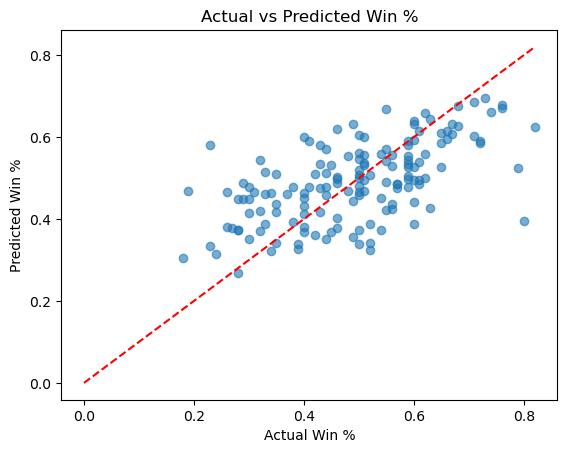

In [25]:
plt.scatter(results["actual win pct"], results["predicted pct"], alpha=0.6)
plt.xlabel("Actual Win %")
plt.ylabel("Predicted Win %")
plt.title("Actual vs Predicted Win %")
plt.plot([0, results["actual win pct"].max()], [0, results["actual win pct"].max()], 'r--')
plt.show()

In [26]:
%whos

Variable                     Type                      Data/Info
----------------------------------------------------------------
RandomForestClassifier       ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
RandomForestRegressor        ABCMeta                   <class 'sklearn.ensemble.<...>t.RandomForestRegressor'>
X_reg_season_win_pct         DataFrame                      season      teamId  <...>\n[746 rows x 35 columns]
X_test_reg_season_win_pct    DataFrame                      season      teamId  <...>\n[150 rows x 35 columns]
X_test_tiers                 DataFrame                      season      teamId  <...>n\n[81 rows x 32 columns]
X_test_wins                  DataFrame                      season      teamId  <...>n\n[81 rows x 32 columns]
X_tiers                      DataFrame                      season      teamId  <...>\n[405 rows x 32 columns]
X_train_reg_season_win_pct   DataFrame                      season      teamId  <...>\n[596 r

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# 1.Features
importances = rf_wins.feature_importances_
features = X_train_wins.columns

# 2.Sorted
fi = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# 3.Top 20
fi.head(20)

,Feature,Importance
15,blocks,0.055886
14,steals,0.052344
25,personal_fouls,0.050539
24,off_rebounds,0.048520
11,assists,0.048463
23,def_rebounds,0.048405
13,turnovers,0.048068
29,avg_margin,0.046806
26,plus_minus_pts,0.046720
7,avg_point_diff,0.045489


<Figure size 800x600 with 0 Axes>

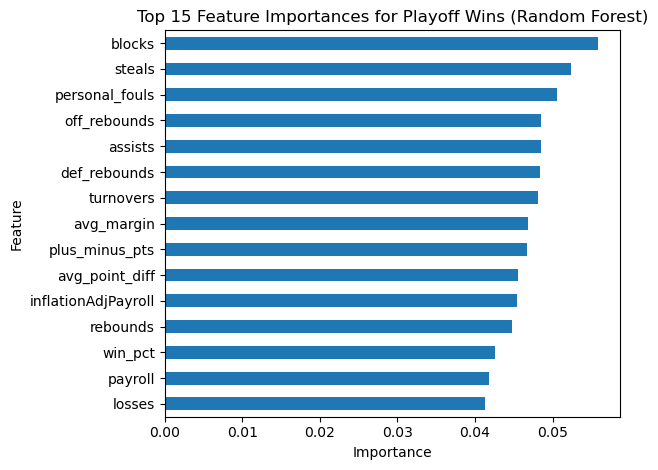

In [29]:
#Plot the top 15 most important features
top_n = 15  # change to 10 if you want a shorter chart

plt.figure(figsize=(8, 6))
fi.head(top_n).plot(
    kind="barh",
    x="Feature",
    y="Importance",
    legend=False
)
plt.gca().invert_yaxis()  # so the most important feature is at the top
plt.title("Top 15 Feature Importances for Playoff Wins (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [30]:
bins = [0, 0.50, 0.65, 1.0]
labels = ['<0.50', '0.50–0.65', '>0.65']

df['win_bin'] = pd.cut(
    df['win_pct'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

NameError: name 'df' is not defined